
# Introduction to the Framingham Heart Disease Dataset

The Framingham Heart Disease Dataset is one of the most popular datasets used in healthcare and machine learning research. It is derived from the Framingham Heart Study, a long-term medical research project designed to identify the major risk factors responsible for cardiovascular diseases. The dataset includes information related to an individual's demographic details, lifestyle habits, medical history, and clinical examination results.

The main objective of this dataset is to develop a machine learning model that can predict whether a person is at risk of developing Coronary Heart Disease (CHD) within the next 10 years. The prediction is represented by the target variable TenYearCHD, where a value of 0 indicates that the person is not expected to develop CHD within the next ten years, while a value of 1 indicates a potential risk of developing the disease during that period.

This dataset is widely used for solving binary classification problems and serves as an excellent resource for learning various stages of the machine learning process. These include data preprocessing, exploratory data analysis (EDA), feature engineering, model building, performance evaluation, and healthcare risk prediction. Several classification algorithms, such as Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM),and K-Nearest Neighbors (KNN), can be applied to analyze the dataset and predict heart disease risk.

## Dataset Summary

* Dataset Name: Framingham Heart Disease Dataset
* Application Domain: Healthcare / Medical
* Total Number of Records: 4,238
* Total Number of Features: 16 (15 input features and 1 target variable)
* Problem Type: Binary Classification
* Target Variable: TenYearCHD
* Prediction Goal: To determine whether an individual is likely to develop Coronary Heart Disease (CHD) within the next 10 years.



Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

Load Dataset

In [3]:
# Load dataset
df = pd.read_csv("C:/Users/psair/Downloads/framingham.csv")

# Display first 5 rows
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Exploratory Data Analysis (EDA)

Dataset Shape

In [11]:

print(df.shape)

(4238, 16)


First 5 Rows

In [12]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Last 5 Rows

In [13]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.00000,0,1,0,313.0,179.0,92.0,25.97,66.0,86.000000,1
4234,1,51,3.0,1,43.0,0.00000,0,0,0,207.0,126.5,80.0,19.71,65.0,68.000000,0
4235,0,48,2.0,1,20.0,0.02963,0,0,0,248.0,131.0,72.0,22.00,84.0,86.000000,0
4236,0,44,1.0,1,15.0,0.00000,0,0,0,210.0,126.5,87.0,19.16,86.0,81.966753,0
4237,0,52,2.0,0,0.0,0.00000,0,0,0,269.0,133.5,83.0,21.47,80.0,107.000000,0


Dataset Information

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4238 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4238 non-null   float64
 5   BPMeds           4238 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4238 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4238 non-null   float64
 13  heartRate        4238 non-null   float64
 14  glucose          4238 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


Statistical Summary

In [15]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.00000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.02963,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.007075,0.500024,11.879230,0.16852,0.076587,0.462763,0.158316,44.326453,22.038097,11.910850,4.070953,12.025177,22.836603,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.410000,75.000000,80.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.00000,0.000000,1.000000,0.000000,262.000000,144.000000,89.875000,28.037500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.00000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Check Missing Values

In [16]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Handle Missing Values

In [17]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Verify Missing Values

In [18]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

Check Duplicate Records

In [19]:
print(df.duplicated().sum())

0


Check Data Types

In [20]:
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


Target Variable Distribution

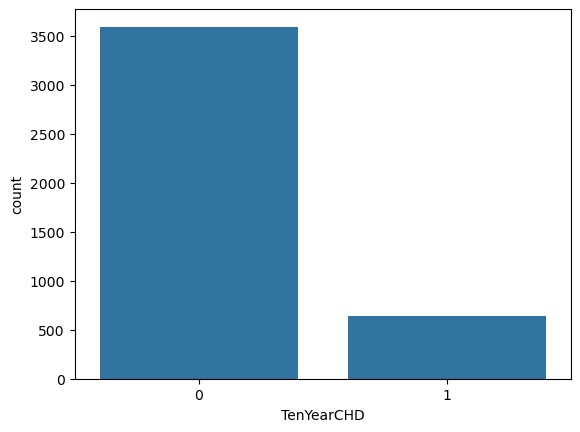

In [21]:
sns.countplot(x='TenYearCHD', data=df)
plt.show()

Correlation Heatmap

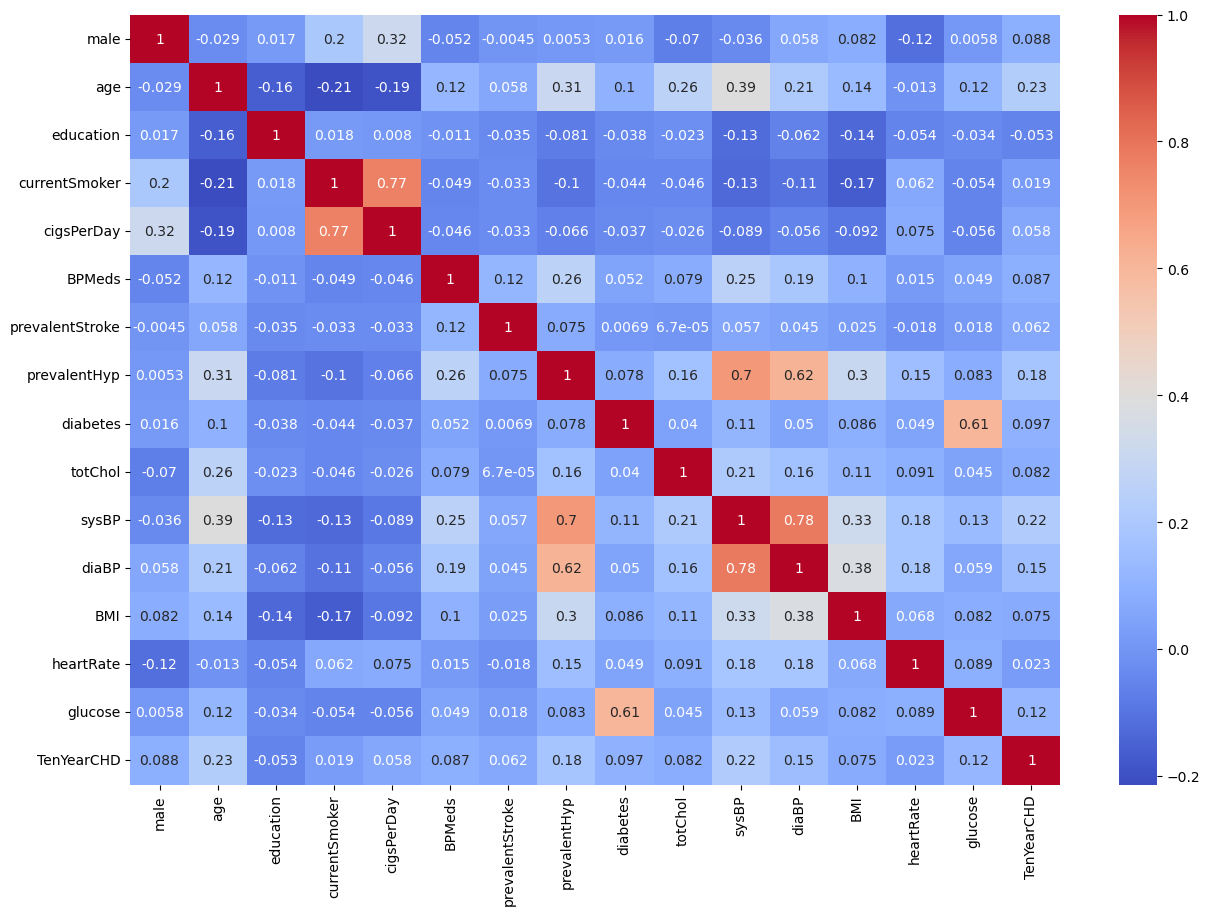

In [22]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Histograms

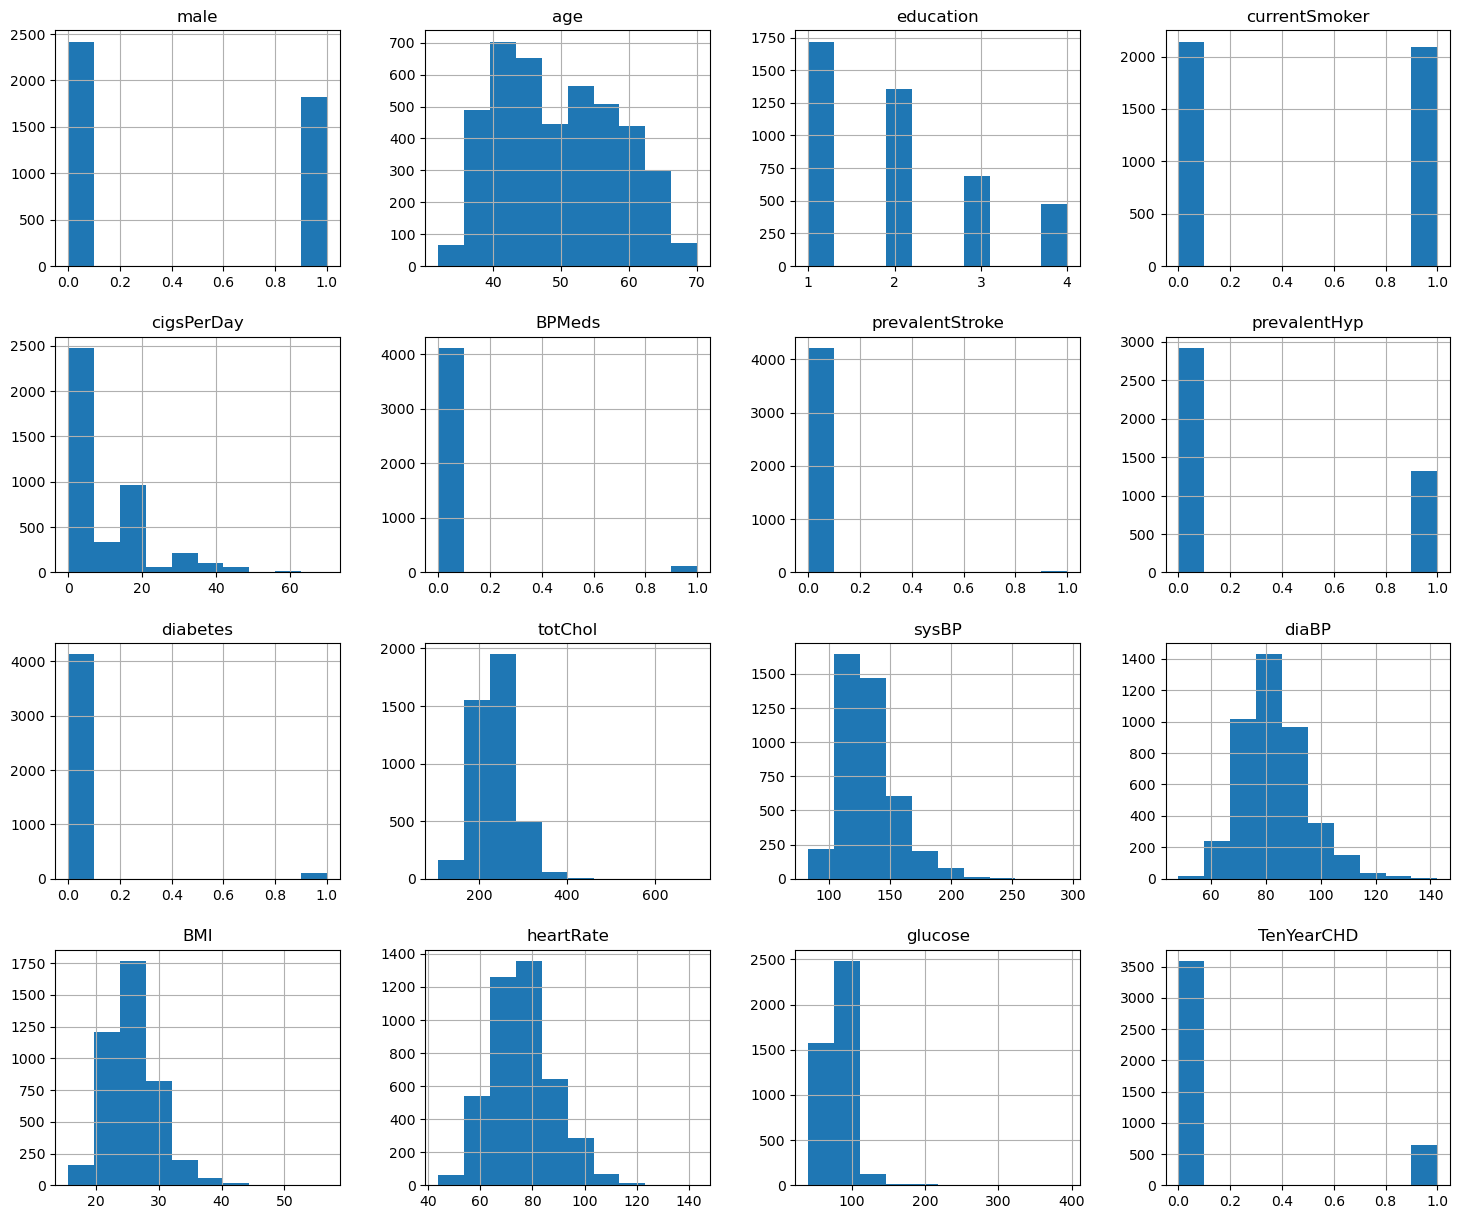

In [23]:
df.hist(figsize=(18,15))
plt.show()

Boxplot

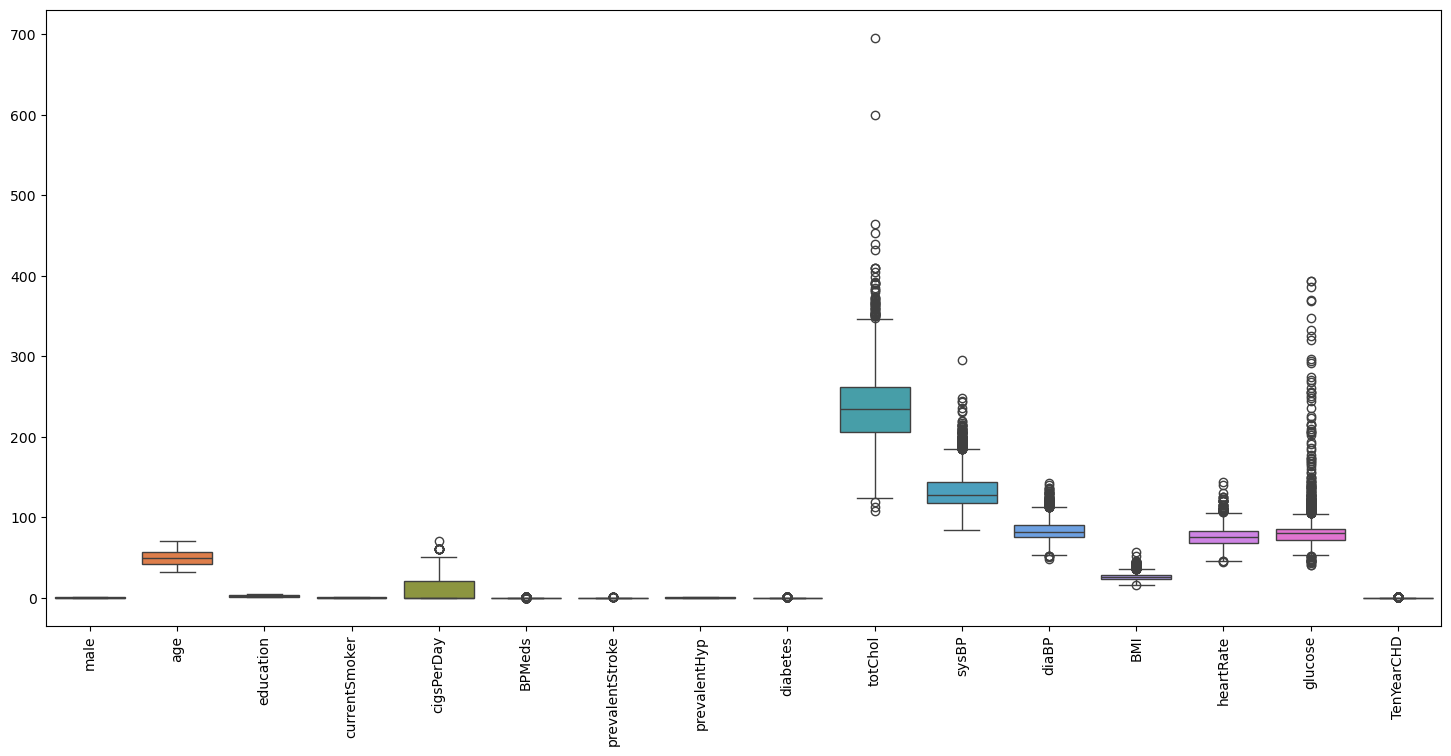

In [24]:
plt.figure(figsize=(18,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

Pairplot 

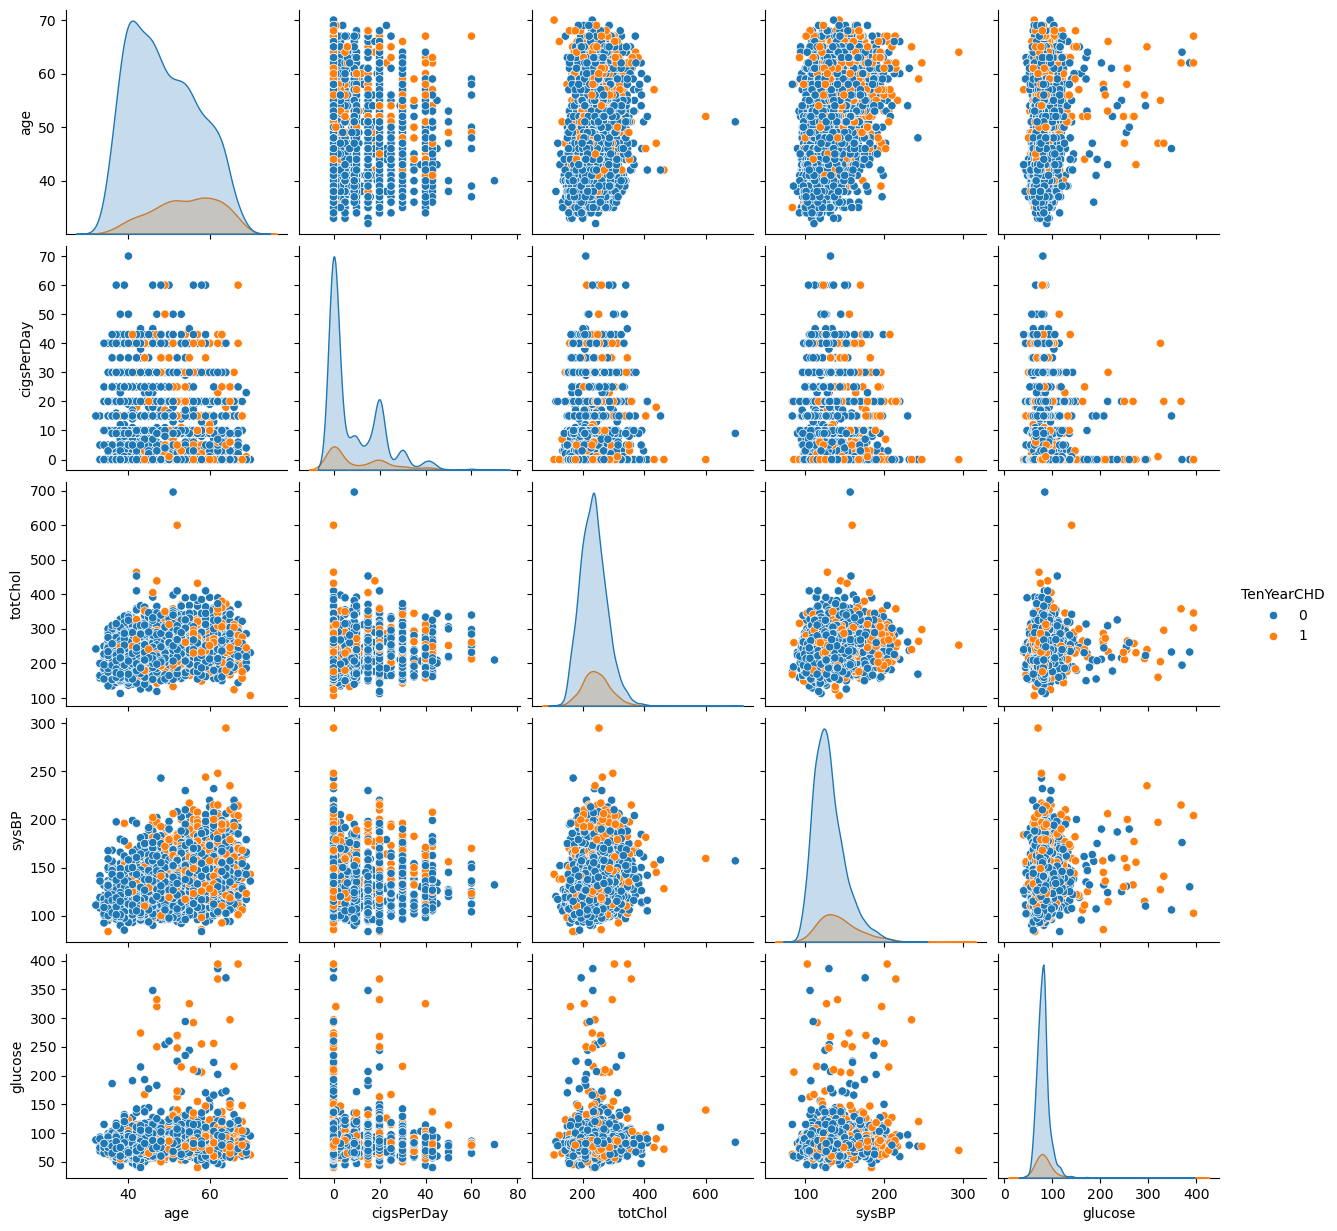

In [25]:
sns.pairplot(
    df[['age','cigsPerDay','totChol','sysBP','glucose','TenYearCHD']],
    hue='TenYearCHD'
)
plt.show()

Feature Selection

In [26]:
# Features (Independent Variables)
X = df.drop('TenYearCHD', axis=1)

# Target (Dependent Variable)
y = df['TenYearCHD']

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4238, 15)
y Shape: (4238,)


Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3390, 15)
(848, 15)


Feature Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_accuracy)

print(classification_report(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.847877358490566
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       719
           1       0.50      0.07      0.12       129

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.80      0.85      0.80       848

[[710   9]
 [120   9]]


Decision Tree

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_accuracy)

print(classification_report(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.7382075471698113
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       719
           1       0.18      0.21      0.20       129

    accuracy                           0.74       848
   macro avg       0.52      0.52      0.52       848
weighted avg       0.75      0.74      0.75       848

[[599 120]
 [102  27]]


Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)

print(classification_report(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.8443396226415094
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.38      0.04      0.07       129

    accuracy                           0.84       848
   macro avg       0.62      0.51      0.49       848
weighted avg       0.78      0.84      0.79       848

[[711   8]
 [124   5]]


Support Vector Machine (SVM)

In [32]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy)

print(classification_report(y_test, svm_pred))

print(confusion_matrix(y_test, svm_pred))

Accuracy: 0.8502358490566038
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       719
           1       0.67      0.03      0.06       129

    accuracy                           0.85       848
   macro avg       0.76      0.51      0.49       848
weighted avg       0.82      0.85      0.79       848

[[717   2]
 [125   4]]


Compare Model Accuracy

In [33]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']

accuracy = [
    lr_accuracy * 100,
    dt_accuracy * 100,
    rf_accuracy * 100,
    svm_accuracy * 100
]

result = pd.DataFrame({
    'Model': models,
    'Accuracy (%)': accuracy
})

print(result)

                 Model  Accuracy (%)
0  Logistic Regression     84.787736
1        Decision Tree     73.820755
2        Random Forest     84.433962
3                  SVM     85.023585


Accuracy Bar Graph

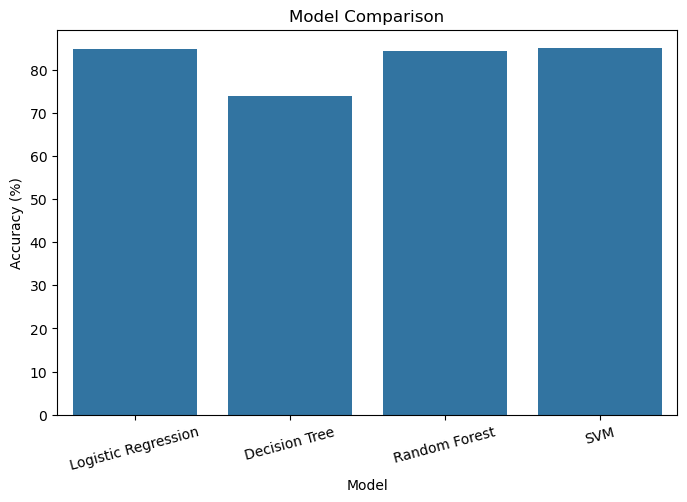

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='Accuracy (%)', data=result)

plt.title("Model Comparison")

plt.xticks(rotation=15)

plt.show()

Best Model

In [35]:
print(result.sort_values(by='Accuracy (%)', ascending=False))

                 Model  Accuracy (%)
3                  SVM     85.023585
0  Logistic Regression     84.787736
2        Random Forest     84.433962
1        Decision Tree     73.820755


Save the Best Model

In [36]:
import pickle

pickle.dump(rf, open("HeartDiseaseModel.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


Load Saved Model

In [37]:
model = pickle.load(open("HeartDiseaseModel.pkl", "rb"))

print("Model Loaded Successfully")

Model Loaded Successfully


Predict New Patient

In [38]:
sample = X.iloc[[0]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("High Risk of Heart Disease")
else:
    print("Low Risk of Heart Disease")

Low Risk of Heart Disease


Display Confusion Matrix 

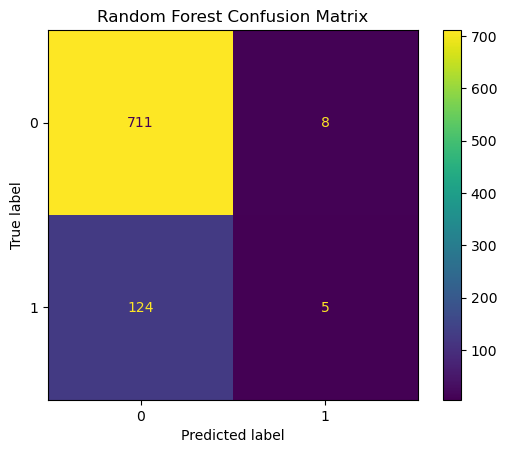

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")
plt.show()

Display Classification Report

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       719
           1       0.38      0.04      0.07       129

    accuracy                           0.84       848
   macro avg       0.62      0.51      0.49       848
weighted avg       0.78      0.84      0.79       848



Feature Importance

In [41]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

            Feature  Importance
10            sysBP    0.133293
1               age    0.125389
12              BMI    0.122547
9           totChol    0.122478
14          glucose    0.118996
11            diaBP    0.115261
13        heartRate    0.094682
4        cigsPerDay    0.050204
2         education    0.042212
0              male    0.020111
7      prevalentHyp    0.017809
5            BPMeds    0.012804
3     currentSmoker    0.012036
8          diabetes    0.007765
6   prevalentStroke    0.004412


Plot Feature Importance

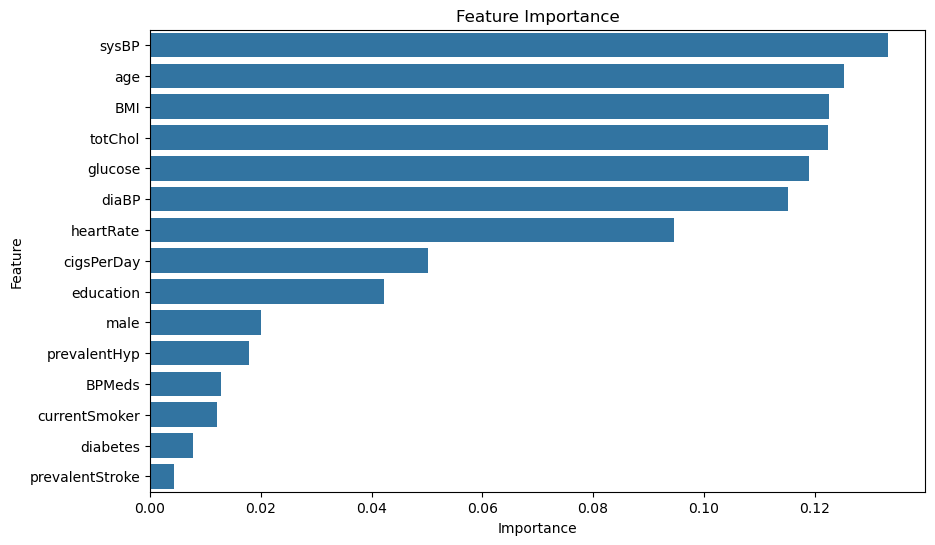

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

Predict Custom Patient

In [45]:
print(X.columns)
print("Number of features:", len(X.columns))

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose'],
      dtype='object')
Number of features: 15


In [46]:
sample = X.iloc[[0]]
sample = scaler.transform(sample)

prediction = model.predict(sample)

if prediction[0] == 1:
    print("High Risk of Heart Disease")
else:
    print("Low Risk of Heart Disease")

Low Risk of Heart Disease


In [47]:
print(len(X.columns))

15


In [49]:
sample = [[39,0,0,0,0,0,0,195,106,70,26.97,80,77,85,0]]

In [50]:
print(X.columns)

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose'],
      dtype='object')


In [51]:


sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Person has High Risk of Heart Disease")
else:
    print("Person has Low Risk of Heart Disease")

Person has Low Risk of Heart Disease


Display Model Accuracy

In [52]:
print("Logistic Regression Accuracy :", lr_accuracy * 100)
print("Decision Tree Accuracy       :", dt_accuracy * 100)
print("Random Forest Accuracy       :", rf_accuracy * 100)
print("SVM Accuracy                 :", svm_accuracy * 100)

Logistic Regression Accuracy : 84.7877358490566
Decision Tree Accuracy       : 73.82075471698113
Random Forest Accuracy       : 84.43396226415094
SVM Accuracy                 : 85.02358490566037


Accuracy Comparison Table

In [53]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy (%)': [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100,
        svm_accuracy * 100
    ]
})

results

,Model,Accuracy (%)
0,Logistic Regression,84.787736
1,Decision Tree,73.820755
2,Random Forest,84.433962
3,SVM,85.023585


Accuracy Bar Chart

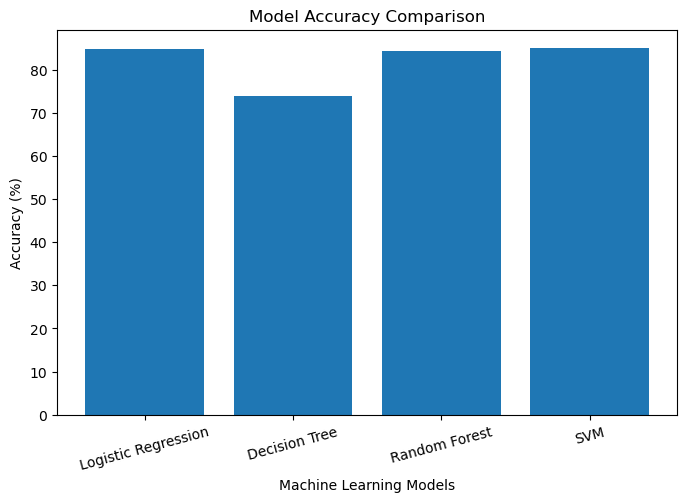

In [54]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy (%)'])

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

Find the Best Model

In [55]:
best_model = results.loc[results['Accuracy (%)'].idxmax()]

print(best_model)

Model                 SVM
Accuracy (%)    85.023585
Name: 3, dtype: object


Save the Best Model

In [56]:
import pickle

pickle.dump(rf, open("HeartDiseaseModel.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


Load the Saved Model

In [57]:
loaded_model = pickle.load(open("HeartDiseaseModel.pkl", "rb"))

print("Model Loaded Successfully")

Model Loaded Successfully


# Conclusion

This project predicts the risk of heart disease using the Framingham Heart Disease dataset. Data preprocessing, exploratory data analysis (EDA), feature scaling, and machine learning models such as Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine were implemented. The models were evaluated using accuracy, confusion matrix, and classification report. Among all the models, the one with the highest accuracy was selected as the final prediction model.